# Assignment 2 - Poject 7 Mixed Precision Training Strategy for VAE and VQ-VAE


## Description
Variational Autoencoders (VAE) and Vector Quantized Variational Autoencoders (VQ-VAE) are powerful generative models used in the field of deep learning for unsupervised learning tasks. This project aims to compare the performance of these models on three benchmark datasets: CIFAR-10, MNIST, and Fashion-MNIST. A key aspect of this comparison will be the use of normal and mixed precision training approaches, which have implications for training efficiency and model accuracy.

### Objectives

 - Implement VAE and VQ-VAE models in a deep learning framework
 - Train and evaluate these models on CIFAR-10, MNIST, and Fashion-MNIST datasets
 - Compare the performance of each model using normal and mixed precision training methods.
- Analyze the effects of precision training on the efficiency and accuracy of the models.

### notes on approach - A

- implimentation
    - VAE and VQ-VAE
- train both on each dataset
- comparison
    - mixed vs normal precision training
- analysis 
    - generation quality and reconstruction quality
    - training efficency
    - accuacay and preformance trade-offs
    

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import os
import time
import pathlib as Path
import sys
import pandas as pd

from torchvision.utils import make_grid

import src.config 
import src.datafunctions 


In [17]:
#Make sure GPU torch is instaled and available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
#Check if GPU is available and set device accordingly
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cuda
GPU: NVIDIA GeForce RTX 5060 Laptop GPU


In [18]:
def show_batch(images, n=8, title="Batch"):
    images = images[:n].cpu()
    grid = make_grid(images, nrow=n, padding=2)
    plt.figure(figsize=(n * 1.5, 2))
    plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray" if images.shape[1] == 1 else None)
    plt.title(title)
    plt.axis("off")
    plt.show()

In [21]:
mnist_train, mnist_test, in_channels, input_size = get_dataloaders(
    data_dir=DATA_DIR,
    dataset_name="mnist",
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
)
fashion_mnist_train, fashion_mnist_test, in_channels, input_size = get_dataloaders(
    data_dir=DATA_DIR,
    dataset_name="fashion-mnist",
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
)
cifar10_train, cifar10_test, in_channels, input_size = get_dataloaders(
    data_dir=DATA_DIR,
    dataset_name="cifar10",
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
)

torch.Size([128, 1, 28, 28]) torch.Size([128])


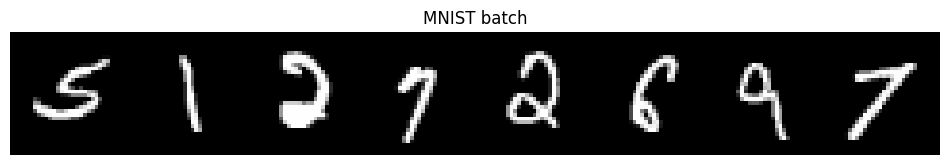

torch.Size([128, 1, 28, 28]) torch.Size([128])


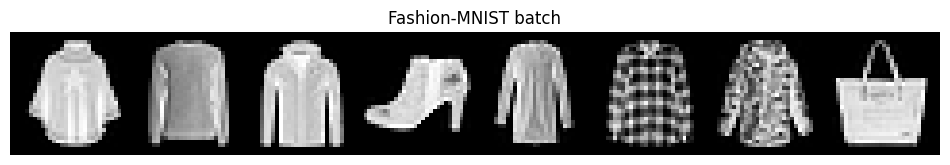

torch.Size([128, 3, 32, 32]) torch.Size([128])


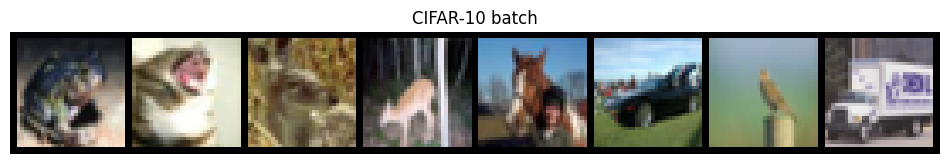

In [24]:
images, labels = next(iter(mnist_train))
images1, labels1 = next(iter(fashion_mnist_train))
images2, labels2 = next(iter(cifar10_train))

print(images.shape, labels.shape)
show_batch(images, title="MNIST batch")
print(images1.shape, labels1.shape)
show_batch(images1, title="Fashion-MNIST batch")
print(images2.shape, labels2.shape)
show_batch(images2, title="CIFAR-10 batch")

this is a test